In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

GPU_LIST = ['A40', 'A100', 'L20', 'L40', 'H800']
BASE = '/Users/zkx/alibaba_simulator/pipeweave/pipetuning_test/demo'

dfs = []
for gpu in GPU_LIST:
    df = pd.read_csv(f'{BASE}/topk_underperforming_{gpu}.csv')
    df['gpu'] = gpu
    dfs.append(df)
data = pd.concat(dfs, ignore_index=True)

data['opt_gain'] = data['optimal_perf'] - data['overall_perf']
data['rel_opt_gain'] = data['opt_gain'] / data['overall_perf']
data['pred_gap'] = data['pred_perf'] - data['overall_perf']
data['improved'] = data['opt_gain'] > 0.01

print(f'Total points: {len(data)}')
print(data.groupby('gpu').size())

Total points: 402
gpu
A100     65
A40      70
H800     61
L20      65
L40     141
dtype: int64


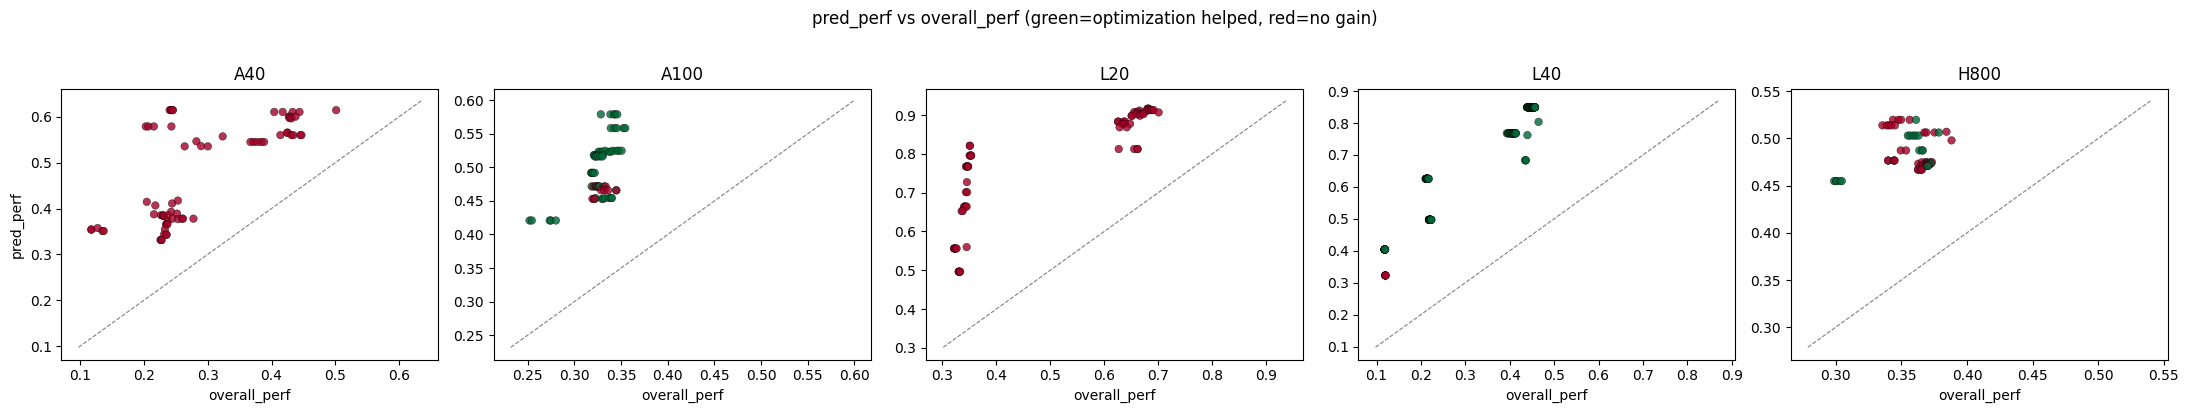

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, gpu in zip(axes, GPU_LIST):
    sub = data[data['gpu'] == gpu]
    ax.scatter(sub['overall_perf'], sub['pred_perf'],
               c=sub['improved'], cmap='RdYlGn', edgecolor='k',
               linewidth=0.3, s=30, alpha=0.8)
    lims = [min(sub['overall_perf'].min(), sub['pred_perf'].min()) - 0.02,
            max(sub['overall_perf'].max(), sub['pred_perf'].max()) + 0.02]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
    ax.set_title(gpu)
    ax.set_xlabel('overall_perf')
axes[0].set_ylabel('pred_perf')
fig.suptitle('pred_perf vs overall_perf (green=optimization helped, red=no gain)', y=1.02)
plt.tight_layout()
plt.show()

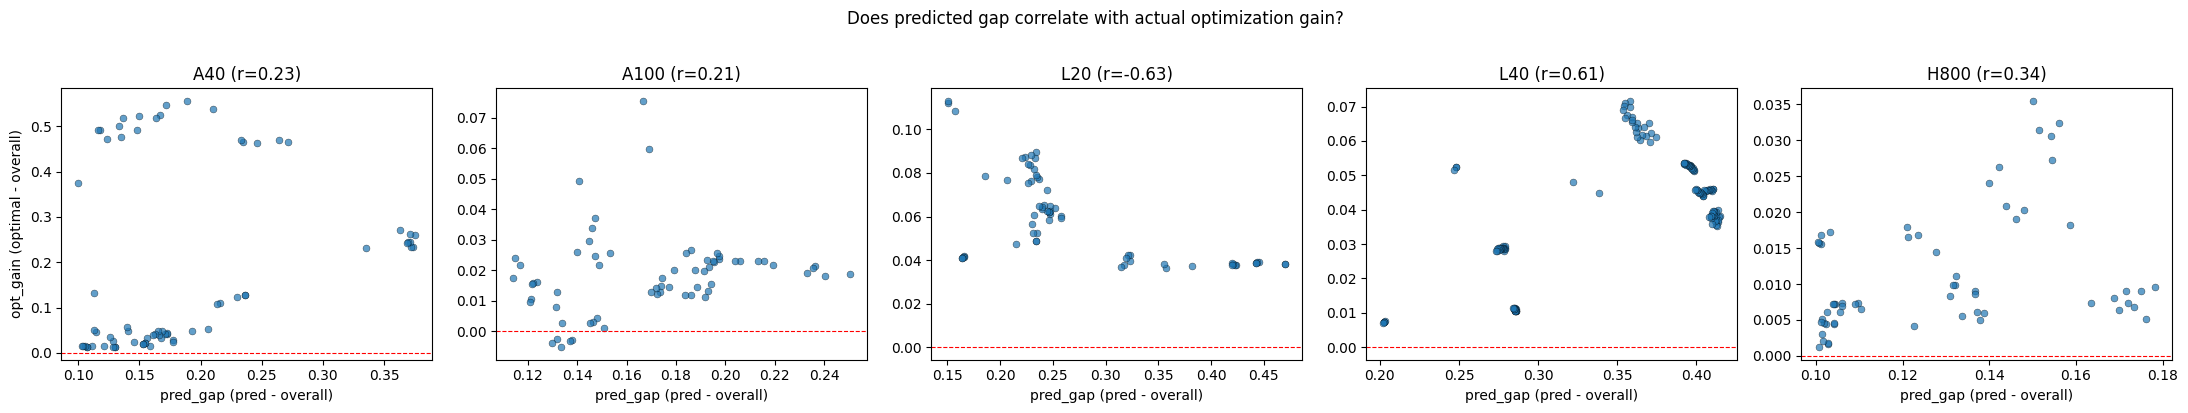

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, gpu in zip(axes, GPU_LIST):
    sub = data[data['gpu'] == gpu]
    ax.scatter(sub['pred_gap'], sub['opt_gain'], s=25, alpha=0.7, edgecolor='k', linewidth=0.3)
    r = sub['pred_gap'].corr(sub['opt_gain'])
    ax.set_title(f'{gpu} (r={r:.2f})')
    ax.set_xlabel('pred_gap (pred - overall)')
    ax.axhline(0, color='r', ls='--', lw=0.8)
axes[0].set_ylabel('opt_gain (optimal - overall)')
fig.suptitle('Does predicted gap correlate with actual optimization gain?', y=1.02)
plt.tight_layout()
plt.show()

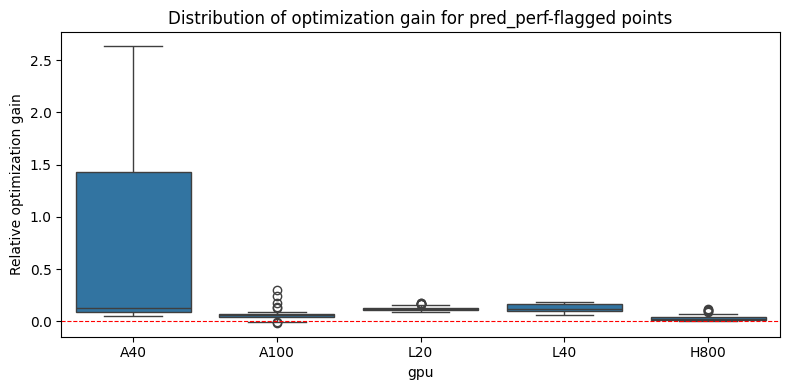

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=data, x='gpu', y='rel_opt_gain', order=GPU_LIST, ax=ax)
ax.set_ylabel('Relative optimization gain')
ax.set_title('Distribution of optimization gain for pred_perf-flagged points')
ax.axhline(0, color='r', ls='--', lw=0.8)
plt.tight_layout()
plt.show()

In [5]:
summary = data.groupby('gpu').agg(
    n_points=('opt_gain', 'size'),
    n_improved=('improved', 'sum'),
    hit_rate=('improved', 'mean'),
    avg_gain=('opt_gain', 'mean'),
    avg_rel_gain=('rel_opt_gain', 'mean'),
    correlation=('pred_gap', lambda x: x.corr(data.loc[x.index, 'opt_gain']))
).loc[GPU_LIST].round(4)

summary['hit_rate'] = (summary['hit_rate'] * 100).round(1).astype(str) + '%'
summary['avg_rel_gain'] = (summary['avg_rel_gain'] * 100).round(1).astype(str) + '%'
summary

,n_points,n_improved,hit_rate,avg_gain,avg_rel_gain,correlation
gpu,,,,,,
A40,70,70,100.0%,0.1914,78.5%,0.2288
A100,65,53,81.5%,0.0184,5.9%,0.2085
L20,65,65,100.0%,0.0594,11.8%,-0.6326
L40,141,136,96.4%,0.0410,12.9%,0.6140
H800,61,21,34.4%,0.0113,3.3%,0.3362
